In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t as Student
from scipy.stats import f as Fisher
from scipy.stats import norm as Normal
from scipy.stats import kstest

In [3]:
x = np.random.uniform(-1, 1, (50, 5))

mean = 2 + 3*x[:, 0] - 2*x[:, 1] + x[:, 2] + x[:, 3] - x[:, 4]

y = np.random.normal(mean, 1.5)

scale = np.hstack([x, y[:, None]])

# a) Мультиколинеарность

In [4]:
baned = []
for i in range (5):
    mask = np.array([True] * i + [False] + [True] * (4 - i), dtype=bool)
    for b in baned:
        mask[b] = False

    psi = np.hstack([np.ones((50, 1)), x[:, mask]])

    F = psi.T @ psi
    b = np.linalg.inv(F) @ psi.T @ x[:,i]
    e = x[:, i] - (psi @ b)
    RSS = e.T @ e
    TSS = np.sum((x[:,i] - np.mean(x[:, i])) ** 2)
    R = (TSS - RSS) / TSS
    print (f'R_{i + 1} = {R}')
    
    if R > 0.7:
        baned.append(i)
    
if len(baned) != 0:
    print (f'Сильно связанные факторы: {np.array(baned)}')
else:
    print ('Факторы не сильно связаны друг с другом')

R_1 = 0.06139733752480175
R_2 = 0.06909478819032744
R_3 = 0.10633447840386609
R_4 = 0.10946416085568453
R_5 = 0.07479253498435476
Факторы не сильно связаны друг с другом


# b) Значимость коэфициентов

In [41]:
psi = np.hstack([np.ones((50, 1)), x])
F = psi.T @ psi
b = np.linalg.inv(F) @ psi.T @ y

print (f'Уравнение линейной регрессии:\ny = {np.round(b[0], 3)} + {np.round(b[1], 3)} * x1 + {np.round(b[2], 3)} * x2 + {np.round(b[3], 3)} * x3 + {np.round(b[4], 3)} * x4 + {np.round(b[5], 3)} * x5 + e')

e = y - (psi @ b)
RSS = e.T @ e
n = psi.shape[0]
p = psi.shape[1]

index_of_less_significant = -1
maximum_p_value = 'inf'

print ('\nПроверка значимости коэфициентов:')
for i in range (0, 6):
    delta_value = b[i] / np.sqrt(RSS * np.linalg.inv(F)[i][i]) * np.sqrt ((n - p))
    p_value = 2 * (1 - Student.cdf(abs(delta_value), n - p))
    print (f'p_value{i} = {p_value}', end='')
    if p_value < 0.05 :
        print (f' -> b{i} значимый коэфициент')
    else:
        print (f' -> b{i} незначимый коэфициент')
    

    if maximum_p_value == 'inf':
        maximum_p_value = p_value
        index_of_less_significant = i
    elif maximum_p_value < p_value:
        maximum_p_value = p_value
        index_of_less_significant = i


print (f'Наименее значимый коэфициент: b{index_of_less_significant}')

Уравнение линейной регрессии:
y = 1.884 + 3.935 * x1 + -1.771 * x2 + 0.74 * x3 + 0.974 * x4 + -0.089 * x5 + e

Проверка значимости коэфициентов:
p_value0 = 1.9967880682258965e-09 -> b0 значимый коэфициент
p_value1 = 2.851052727237402e-12 -> b1 значимый коэфициент
p_value2 = 9.858812684448992e-05 -> b2 значимый коэфициент
p_value3 = 0.09969392689099554 -> b3 незначимый коэфициент
p_value4 = 0.027366020226576637 -> b4 значимый коэфициент
p_value5 = 0.8461436845114765 -> b5 незначимый коэфициент
Наименее значимый коэфициент: b5


# c) Коэфициент детерминации

In [6]:
TSS = np.sum((y - np.mean(y)) ** 2)
R = (TSS - RSS) / TSS

print (f'коэфициент детерминации R = {R}')

delta_value = (R * (n - p)) / ((1 - R) * (p -1))
p_value = 1 - Fisher.cdf(delta_value, n-p, p-1)

print (f'p_value = {p_value} ', end = '')
if p_value < 0.05:
    print ('-> модель значима')
else:
    print ('-> модель незначима')

коэфициент детерминации R = 0.7116606465208759
p_value = 0.001341407957493379 -> модель значима


# d) Доверительный интервал

In [7]:
psi0 = np.array([1, 0, 0, 0, 0, 0])

y0 = psi0 @ b

t_quant = Student.ppf((1 + 0.95)/2, n-p)
delta = t_quant * np.sqrt(1 + psi0 @ np.linalg.inv(F) @ psi0.T) * np.sqrt(RSS/(n-p))

print (f'y(0,0,0,0,0) = {y0}')
print (f'Доверительный интервал:\n({y0-delta}, {y0+delta})')

y(0,0,0,0,0) = 1.884487079266047
Доверительный интервал:
(-1.4050348733974634, 5.1740090319295575)


# e) Независимость ошибок

In [8]:
I = 0
for i in range (len(e)):
    for j in range (i+1, len(e)):
        if e[j] < e[i]:
            I += 1

delta_value = (I - n * (n - 1)/ 4) / (np.sqrt (n**3 / 36))

p_value = 2 * (1 - Normal.cdf(delta_value, 0, 1))
print (f'p_value = {p_value}', end = ' ')
if p_value > 0.05:
    print ('ошибки независимы')
else:
    print ('ошибки зависимы')

p_value = 0.206119885077096 ошибки независимы


# f) Нормальность ошибок

In [9]:
N = 50000
sigma_wave = np.var(e, ddof=1)
delta_value, _ =  kstest(e, 'norm', args=(0, sigma_wave**0.5))

all_deltas = []
for k in range (N):
    e_star = np.random.normal(0, sigma_wave, 50)
    sigma_wave_star = np.var(e_star, ddof=1)
    all_deltas.append(kstest(e_star, 'norm', args=(0, sigma_wave_star**0.5))[0])

all_deltas = np.sort(np.array(all_deltas))
mask = (all_deltas >= delta_value)
m = np.count_nonzero(mask)
p_value = m/N

print (f'p_value = {p_value} ', end='')
if p_value > 0.05:
    print ('-> нет оснований отвергать нормальный закон распределения ошибок')
else:
    print ('-> ошибки не нормально распределены')

p_value = 0.73506 -> нет оснований отвергать нормальный закон распределения ошибок


# g) Исследование на выбросы

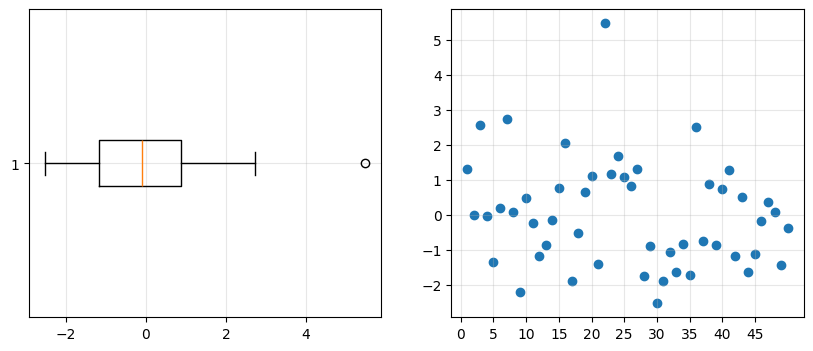

выброс: 5.466542338212785


In [10]:
_, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].boxplot(e, vert=False)

i = np.arange(1, 50.5, 1)

ax[1].scatter(i, e)

ax[1].set_xticks(np.arange(0, 50, 5))
ax[0].grid(alpha=0.3)
ax[1].grid(alpha=0.3)
plt.show()

print (f'выброс: {e[21]}')

# h) Кросс-проверка регрессий

In [17]:
CVSS = 0
for i in range (n):
    mask = np.array([True] * i + [False] + [True] * ((n-1) - i))
    x_i = x[mask]
    y_i = y[mask]
    
    psi = np.hstack([np.ones((49, 1)), x_i])

    F = psi.T @ psi
    b = np.linalg.inv(F) @ psi.T @ y_i

    psi_test = np.hstack([1, x[i]])
    
    CVSS_i = (y[i] - psi_test @ b) ** 2
    CVSS += CVSS_i

Rcvss = (TSS - CVSS) / (TSS)
print (f'CVSS = {CVSS}')
print (f'R_cvss = {Rcvss}')
print (f'R = {R}')

CVSS = 141.12535231796514
R_cvss = 0.644482333242356
R = 0.7116606465208759


# i) Адекватность регрессии

In [25]:
fix_x = x[0]
y_measured = np.random.normal(2 + 3 * fix_x[0] - 2 * fix_x[1] + fix_x[2] + fix_x[3] - fix_x[4], 1.5, 5)

sigma_new = 1/(len(y_measured) - 1) * np.sum((y_measured - np.mean(y_measured))**2)

delta_value = RSS/(sigma_new * (n - p))

p_value = 1 - Fisher.cdf(delta_value, n-p, len(y_measured)-1)

print (f'p_value = {p_value} ', end = '')
if p_value > 0.05:
    print ('регрессия адекватная')
else:
    print ('регрессия плохая')

p_value = 0.362553413863157 регрессия адекватная


# j) Удалить переменную

In [53]:
mask = np.array([True] * 6)
mask[index_of_less_significant] = False

psi_new = psi[:, mask]
F_new = psi_new.T @ psi_new

b_new = np.linalg.inv(F_new) @ psi_new.T @ y

indeces = np.arange(0, 6, 1)[mask]

print (f'Новое уравнение линейной регрессии:\ny = {np.round(b_new[0], 3)} + {np.round(b_new[1], 3)} * x{indeces[1]} + {np.round(b_new[2], 3)} * x{indeces[2]} + {np.round(b_new[3], 3)} * x{indeces[3]} + {np.round(b_new[4], 3)} * x{indeces[4]} + e')

e_new = y - (psi_new @ b_new)

RSS_new = e_new.T @ e_new

delta_value = (RSS_new - RSS) * (n - p) / (RSS * 1)

p_value = 1 - Fisher.cdf(delta_value, 1, n - p)

print (f'p_value = {p_value} ', end='')
if p_value > 0.05:
    print ('не можем считать изменения значимыми (хорошее упрощение)')
else:
    print ('изменения значимы (плохое упрощение)')


Новое уравнение линейной регрессии:
y = 1.898 + 3.949 * x1 + -1.756 * x2 + 0.73 * x3 + 0.969 * x4 + e
p_value = 0.8461436845114633 не можем считать изменения значимыми (хорошее упрощение)


In [55]:
print ('\nПроверка значимости коэфициентов новой регрессии:')
for i in range (0, 5):
    delta_value = b_new[i] / np.sqrt(RSS_new * np.linalg.inv(F_new)[i][i]) * np.sqrt ((n - p - 1))
    p_value = 2 * (1 - Student.cdf(abs(delta_value), n - p - 1))
    print (f'p_value{i} = {p_value}', end='')
    if p_value < 0.05 :
        print (f' -> b{i} значимый коэфициент')
    else:
        print (f' -> b{i} незначимый коэфициент')
    


Проверка значимости коэфициентов новой регрессии:
p_value0 = 1.0087066737440864e-09 -> b0 значимый коэфициент
p_value1 = 3.027134098942952e-12 -> b1 значимый коэфициент
p_value2 = 0.00010546440588021788 -> b2 значимый коэфициент
p_value3 = 0.10609816448890497 -> b3 незначимый коэфициент
p_value4 = 0.0297704250806885 -> b4 значимый коэфициент


In [56]:
TSS = np.sum((y - np.mean(y)) ** 2)
R_new= (TSS - RSS_new) / TSS

print (f'коэфициент детерминации R = {R}')

delta_value = (R_new * (n - p - 1)) / ((1 - R_new) * (p - 2))
p_value = 1 - Fisher.cdf(delta_value, n-p - 1, p-2)

print (f'p_value = {p_value} ', end = '')
if p_value < 0.05:
    print ('-> модель значима')
else:
    print ('-> модель незначима')

коэфициент детерминации R = 0.7116606465208759
p_value = 0.0028216636543768603 -> модель значима


# k) Сравнение бутстрапом

In [66]:
h_wave = RSS_new - RSS
mask = np.array([True] * 6)
mask[index_of_less_significant] = False

deltas = []
for _ in range (1000):
    indeces = np.random.randint(0, 50, 50)
    x_star = x[indeces]
    y_star = y[indeces]

    psi_star = np.hstack([np.ones((50, 1)), x_star])
    F_star = psi_star.T @ psi_star
    b_star = np.linalg.inv(F_star) @ psi_star.T @ y_star

    e_star = y_star - psi_star @ b_star
    RSS_star = e_star.T @ e_star

    psi_star_new = psi_star[:, mask]
    F_star_new = psi_star_new.T @ psi_star_new
    b_star_new = np.linalg.inv(F_star_new) @ psi_star_new.T @ y_star

    e_star_new = y_star - psi_star_new @ b_star_new
    RSS_star_new = e_star_new.T @ e_star_new

    h_wave_star = RSS_star_new - RSS_star
    deltas.append(h_wave_star - h_wave)

deltas = np.sort(np.array(deltas))
print (f'Доверительный интервал:\n({h_wave - deltas[999]} < h < {h_wave - deltas[49]})')

Доверительный интервал:
(-23.36343514534039 < h < 0.18998528084038924)
